# Prosumption & Price EDA -- Magnitude, Seasonality, Heteroskedasticity

Four questions, each answered on the full processed dataset (2018-01-01 to 2020-06-30 --
train + validation + test, not just the sealed test year, since these are properties of
the underlying process rather than of any evaluation split):

1. **Magnitude and seasonality of prosumption** -- how big is it, and how much does that
   change across the year?
2. **Strength of the diurnal and annual solar cycle** -- how much of the day/year does
   solar irradiance actually structure?
3. **Degree of heteroskedasticity in prosumption across the day** -- does the *spread* of
   prosumption vary by hour, not just its level? This is the direct empirical motivation
   for a probabilistic (quantile) forecaster rather than a point forecaster with a fixed
   uncertainty band: if variance were constant across hours, one global noise band would
   suffice; if it isn't, the forecaster needs hour-specific uncertainty.
4. **Distribution of imbalance prices around day-ahead prices** -- how does `imb` deviate
   from `da`, and is that deviation symmetric/thin-tailed enough for a Normal assumption,
   or does it need something heavier-tailed (as `power_price_eda.ipynb` chose a Student-t
   for, elsewhere in this project)?

Complements rather than duplicates `2_eda/power_price_eda.ipynb` (price proxy
construction), `2_eda/seasonal_price_patterns.ipynb` (price-spread-vs-solar correlation),
and `2_eda/wpd_eda.ipynb` (raw source-data EDA) -- this notebook works from the final
merged `df_full.csv` and asks four specific, direct questions rather than building a
downstream artefact.

## Setup

In [20]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pyprojroot import here

DATA_DIR = here() / "1_data" / "processed"
df = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
if df.index.tz is None:
    df.index = df.index.tz_localize("UTC")

TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
VAL_START   = pd.Timestamp("2019-01-01 00:00:00+00:00")
TEST_START  = pd.Timestamp("2019-07-01 00:00:00+00:00")
TEST_END    = pd.Timestamp("2020-06-30 23:00:00+00:00")

df = df.loc[:TEST_END].copy()
df["hour"] = df.index.hour
df["month"] = df.index.month
df["calendar_month"] = df.index.strftime("%Y-%m")

print(f"n_hours={len(df)}  range={df.index[0]} to {df.index[-1]}")
na_counts = df[["prosumption", "solar_irrad", "da", "imb"]].isna().sum()
print(f"raw NaN counts (this file, pre-imputation -- the training/eval pipeline imputes "
      f"these via reindex_and_impute, this notebook does not): {na_counts.to_dict()}")
df[["prosumption", "solar_irrad", "da", "imb"]].describe().round(3)

n_hours=23304  range=2017-11-03 00:00:00+00:00 to 2020-06-30 23:00:00+00:00
raw NaN counts (this file, pre-imputation -- the training/eval pipeline imputes these via reindex_and_impute, this notebook does not): {'prosumption': 20, 'solar_irrad': 0, 'da': 0, 'imb': 0}


,prosumption,solar_irrad,da,imb
count,23284.000,23304.000,23304.000,23304.000
mean,2.221,141.990,46.262,45.812
std,1.402,223.444,16.235,26.011
min,-2.180,0.000,-38.776,-123.404
25%,1.590,0.000,35.628,32.559
50%,2.270,3.720,45.526,44.250
75%,3.080,210.638,55.886,57.751
max,5.920,934.750,271.226,695.000


## 1. Magnitude and seasonality of prosumption

Full time series first (daily mean, to smooth hourly noise while keeping the whole
2.5-year span visible), then the seasonal pattern isolated by pooling all years onto a
single calendar-month axis -- the within-month box shows year-to-year spread at that
point in the seasonal cycle, not just a single realisation of it.

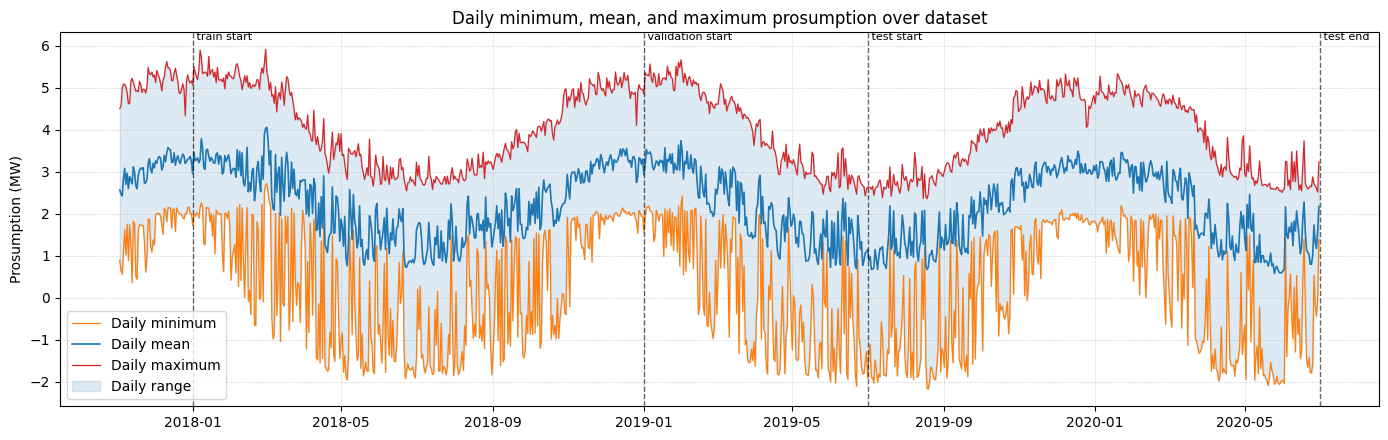

daily minimum: mean=0.260 MW  overall min=-2.180 MW
daily mean: mean=2.221 MW  overall min=0.580 MW  overall max=4.062 MW
daily maximum: mean=4.017 MW  overall max=5.920 MW


In [21]:
daily_min = df["prosumption"].resample("24h").min()
daily_mean = df["prosumption"].resample("24h").mean()
daily_max = df["prosumption"].resample("24h").max()

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(daily_min.index, daily_min.values, color="C1",
    linewidth=0.9, label="Daily minimum")
ax.plot(daily_mean.index, daily_mean.values, color="C0",
    linewidth=1.2, label="Daily mean")
ax.plot(daily_max.index, daily_max.values, color="C3",
    linewidth=0.9, label="Daily maximum")
ax.fill_between(
    daily_min.index,
    daily_min.values,
    daily_max.values,
    color="C0",
    alpha=0.15,
    label="Daily range",
)

for split_date, label in [
    (TRAIN_START, "train start"),
    (VAL_START, "validation start"),
    (TEST_START, "test start"),
    (TEST_END, "test end"),
]:
    ax.axvline(split_date, color="black", linestyle="--",
           linewidth=1, alpha=0.6)
    ax.text(split_date, ax.get_ylim()[1], f" {label}",
        fontsize=8, va="top")

ax.set_ylabel("Prosumption (MW)")
ax.set_title("Daily minimum, mean, and maximum prosumption over dataset")
ax.legend()
ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

print(
    f"daily minimum: mean={daily_min.mean():.3f} MW  "
    f"overall min={daily_min.min():.3f} MW"
)
print(
    f"daily mean: mean={daily_mean.mean():.3f} MW  "
    f"overall min={daily_mean.min():.3f} MW  "
    f"overall max={daily_mean.max():.3f} MW"
)
print(
    f"daily maximum: mean={daily_max.mean():.3f} MW  "
    f"overall max={daily_max.max():.3f} MW"
)

## 2. Strength of the diurnal and annual solar cycle

Diurnal and annual profiles separately, then combined as a heatmap so their interaction
(e.g. summer's diurnal swing being far larger than winter's) is visible in one figure.

Heteroskedasticity itself is not stationary across the year either -- worth checking the
hourly std pattern separately by season, since a forecaster trained on a pooled hourly
std pattern could still miss season-specific structure.

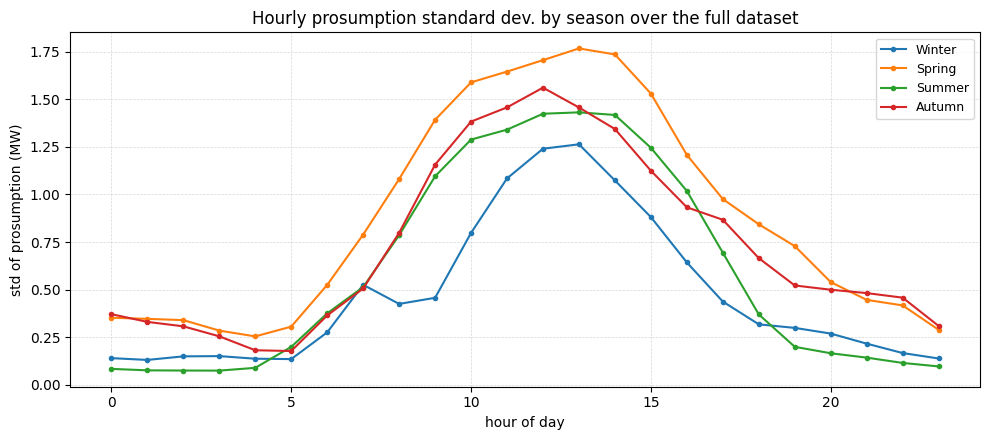

In [22]:
SEASON_MONTHS = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8], "Autumn": [9, 10, 11]}
fig, ax = plt.subplots(figsize=(10, 4.5))
for season, months in SEASON_MONTHS.items():
    sub = df[df["month"].isin(months)]
    hstd = sub.groupby("hour")["prosumption"].std()
    ax.plot(hstd.index, hstd.values, "-o", markersize=3, label=season)
ax.set_xlabel("hour of day")
ax.set_ylabel("std of prosumption (MW)")
ax.set_title("Hourly prosumption standard dev. by season over the full dataset")
ax.legend(fontsize=9)
ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

## 4. Distribution of imbalance prices around day-ahead prices

`spread = imb - da`: how far, and in what shape, does the realised imbalance price
deviate from the day-ahead price. A scatter against the 45-degree line shows the same
relationship without collapsing it to one number, and a Normal-vs-empirical comparison
checks whether the tails are heavy enough to matter (this project's own price-proxy
construction, `power_price_eda.ipynb`, chose a Student-t specifically because of this).

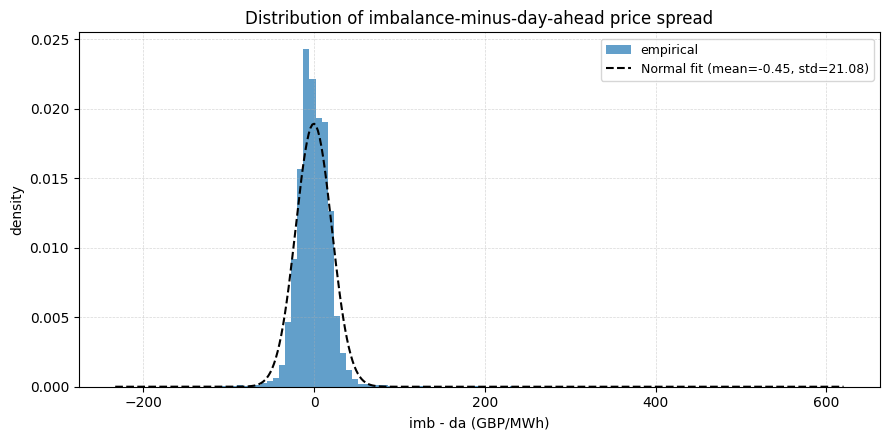

mean=-0.450  std=21.080  skew=3.921  excess_kurtosis=82.758  (Normal: skew=0, excess kurtosis=0 -- positive excess kurtosis = fatter tails than Normal)


In [23]:
spread = df["imb"] - df["da"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(spread, bins=120, density=True, color="C0", alpha=0.7, label="empirical")
x = np.linspace(spread.min(), spread.max(), 400)
ax.plot(x, stats.norm.pdf(x, spread.mean(), spread.std()), "k--", linewidth=1.5,
        label=f"Normal fit (mean={spread.mean():.2f}, std={spread.std():.2f})")
ax.set_xlabel("imb - da (GBP/MWh)")
ax.set_ylabel("density")
ax.set_title("Distribution of imbalance-minus-day-ahead price spread")
ax.legend(fontsize=9)
ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

print(f"mean={spread.mean():.3f}  std={spread.std():.3f}  "
      f"skew={stats.skew(spread):.3f}  excess_kurtosis={stats.kurtosis(spread):.3f}  "
      f"(Normal: skew=0, excess kurtosis=0 -- positive excess kurtosis = fatter tails than Normal)")

Same fat-tail check as `power_price_eda.ipynb`'s own Student-t fit (that notebook fits
`da - imb`, on the training split only, for building the decision-time price-uncertainty
proxy) -- recreated here as `imb - da` on the full dataset, matching this notebook's own
`spread` convention above and its own descriptive (not proxy-construction) purpose, so the
sign/scale is directly comparable to the Normal fit and Q-Q plot already shown.

## 5. Bimodality of midday prosumption, by season

Section 2's solar heatmap already shows the diurnal solar peak sitting squarely around
midday. If clear-sky and overcast days form two fairly distinct regimes rather than a
smooth continuum, that could show up as bimodality specifically in the midday-hour
distribution (as opposed to the full 24-hour distribution, where the diurnal cycle itself
would dominate any such effect): a clear day should depress midday prosumption sharply via
solar generation, an overcast day should barely move it.

Midday fixed at **11:00-14:00** (same clock hours for every season, for a fair
comparison). Two diagnostics per season alongside the histogram: **Sarle's bimodality
coefficient** `BC = (skew^2+1)/kurtosis` (Pearson kurtosis; `BC > 5/9 (~0.555)` is the
conventional rule-of-thumb threshold favouring bimodality over unimodality, not a formal
test), and a **1- vs 2-component Gaussian Mixture Model** comparison by BIC (lower
better) -- a more direct test of whether a two-mode model actually explains the data
better once model complexity is penalised.

In [24]:
from sklearn.mixture import GaussianMixture

MIDDAY_HOURS = [11, 12, 13, 14]
SEASON_ORDER = ["Spring", "Summer", "Autumn", "Winter"]
SEASON_COLORS = {"Spring": "C2", "Summer": "C1", "Autumn": "C5", "Winter": "C0"}

midday = df[df["hour"].isin(MIDDAY_HOURS)].copy()
midday["season"] = midday["month"].map(
    lambda m: next(s for s, months in SEASON_MONTHS.items() if m in months)
)


def bimodality_stats(x: np.ndarray) -> dict:
    skew = stats.skew(x)
    kurt = stats.kurtosis(x, fisher=False)  # Pearson kurtosis (normal = 3)
    bc = (skew**2 + 1) / kurt

    gmm1 = GaussianMixture(n_components=1, random_state=0).fit(x.reshape(-1, 1))
    gmm2 = GaussianMixture(n_components=2, random_state=0).fit(x.reshape(-1, 1))
    bic1, bic2 = gmm1.bic(x.reshape(-1, 1)), gmm2.bic(x.reshape(-1, 1))

    order = np.argsort(gmm2.means_.ravel())
    means2 = gmm2.means_.ravel()[order]
    weights2 = gmm2.weights_[order]

    return dict(bc=bc, bic1=bic1, bic2=bic2, gmm2_means=means2, gmm2_weights=weights2,
                gmm1=gmm1, gmm2=gmm2)


MIDDAY_STATS = {}
for season in SEASON_ORDER:
    x = midday.loc[midday["season"] == season, "prosumption"].dropna().to_numpy()
    MIDDAY_STATS[season] = bimodality_stats(x)
    s = MIDDAY_STATS[season]
    print(f"{season:8s}  n={len(x)}  BC={s['bc']:.3f}  BIC(1-comp)={s['bic1']:.1f}  "
          f"BIC(2-comp)={s['bic2']:.1f}  delta={s['bic1']-s['bic2']:+.1f}  "
          f"2-comp means={np.round(s['gmm2_means'],3)}  weights={np.round(s['gmm2_weights'],3)}")

Spring    n=1099  BC=0.584  BIC(1-comp)=4316.6  BIC(2-comp)=3944.6  delta=+371.9  2-comp means=[-1.352  1.313]  weights=[0.37 0.63]
Summer    n=855  BC=0.621  BIC(1-comp)=3024.6  BIC(2-comp)=2649.5  delta=+375.1  2-comp means=[-1.601  0.527]  weights=[0.346 0.654]
Autumn    n=840  BC=0.574  BIC(1-comp)=3031.3  BIC(2-comp)=2884.1  delta=+147.1  2-comp means=[-0.038  2.439]  weights=[0.395 0.605]
Winter    n=1084  BC=0.576  BIC(1-comp)=3428.0  BIC(2-comp)=3155.8  delta=+272.2  2-comp means=[1.524 3.355]  weights=[0.386 0.614]


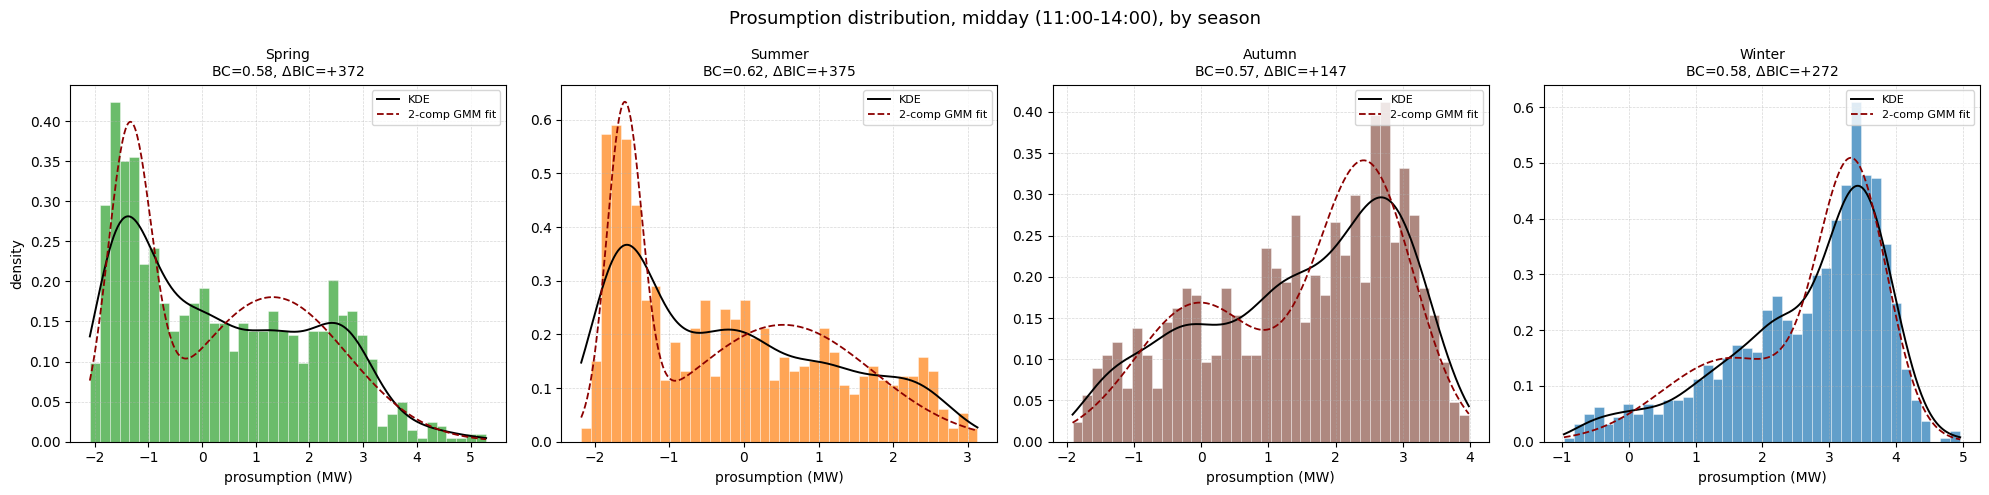

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, season in zip(axes, SEASON_ORDER):
    x = midday.loc[midday["season"] == season, "prosumption"].dropna().to_numpy()
    s = MIDDAY_STATS[season]

    ax.hist(x, bins=40, color=SEASON_COLORS[season], alpha=0.7, density=True, edgecolor="white", linewidth=0.4)

    xs = np.linspace(x.min(), x.max(), 400)
    kde = stats.gaussian_kde(x)
    ax.plot(xs, kde(xs), color="black", linewidth=1.4, label="KDE")

    if s["bic2"] < s["bic1"]:
        dens2 = np.exp(s["gmm2"].score_samples(xs.reshape(-1, 1)))
        ax.plot(xs, dens2, color="darkred", linestyle="--", linewidth=1.3, label="2-comp GMM fit")

    ax.set_title(f"{season}\nBC={s['bc']:.2f}, ${{\\Delta}}$BIC={s['bic1']-s['bic2']:+.0f}", fontsize=10)
    ax.set_xlabel("prosumption (MW)")
    ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("density")
fig.suptitle("Prosumption distribution, midday (11:00-14:00), by season", fontsize=13)
fig.tight_layout()
plt.show()

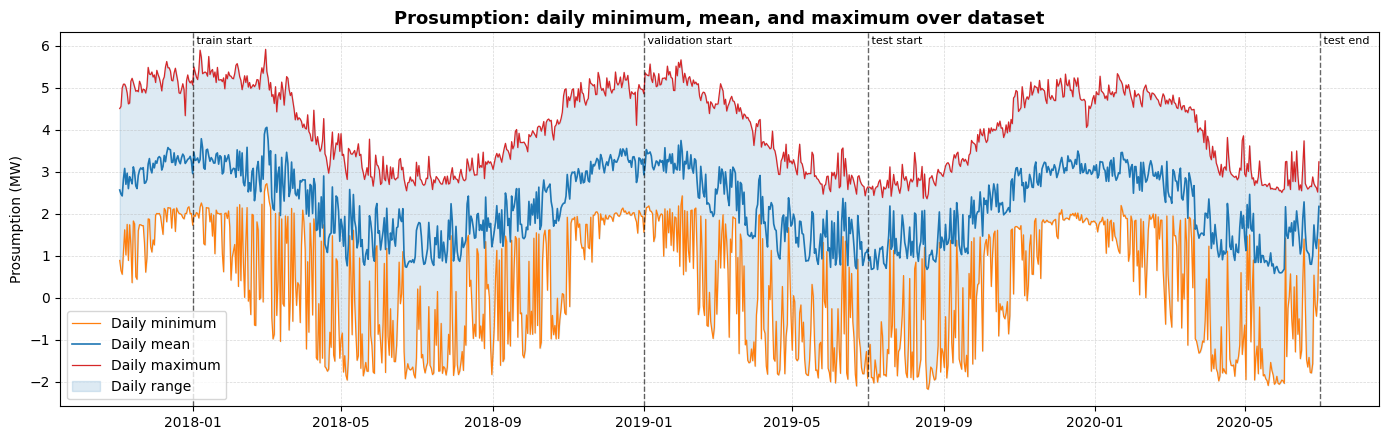

In [26]:
daily_min = df["prosumption"].resample("24h").min()
daily_mean = df["prosumption"].resample("24h").mean()
daily_max = df["prosumption"].resample("24h").max()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily_min.index, daily_min, color="C1", linewidth=0.9, label="Daily minimum")
ax.plot(daily_mean.index, daily_mean, color="C0", linewidth=1.2, label="Daily mean")
ax.plot(daily_max.index, daily_max, color="C3", linewidth=0.9, label="Daily maximum")
ax.fill_between(
    daily_min.index, daily_min, daily_max,
    color="C0", alpha=0.15, label="Daily range"
)

for split_date, label in [
    (TRAIN_START, "train start"),
    (VAL_START, "validation start"),
    (TEST_START, "test start"),
    (TEST_END, "test end"),
]:
    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
    
    # Places text near the top of each vertical line
    ax.text(
        split_date, 
        ax.get_ylim()[1] * 0.95, 
        f" {label}", 
        rotation=0, 
        verticalalignment="bottom", 
        fontsize=8, 
        color="black"
    )
ax.set_ylabel("Prosumption (MW)")
ax.set_title("Prosumption: daily minimum, mean, and maximum over dataset", fontsize=13, fontweight="bold")
ax.legend(loc="lower left")
ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

### Hourly variability by season, alongside its midday distributional shape

Combines the hourly-std-by-season line plot (top) with the midday bimodality histograms
from Section 5 (bottom, one panel per season) into a single figure -- the top panel shows
*when* in the day and *how much* variability differs by season, the bottom panels show
*what shape* that variability actually takes specifically at its midday peak.

/tmp/ipykernel_628521/745215123.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


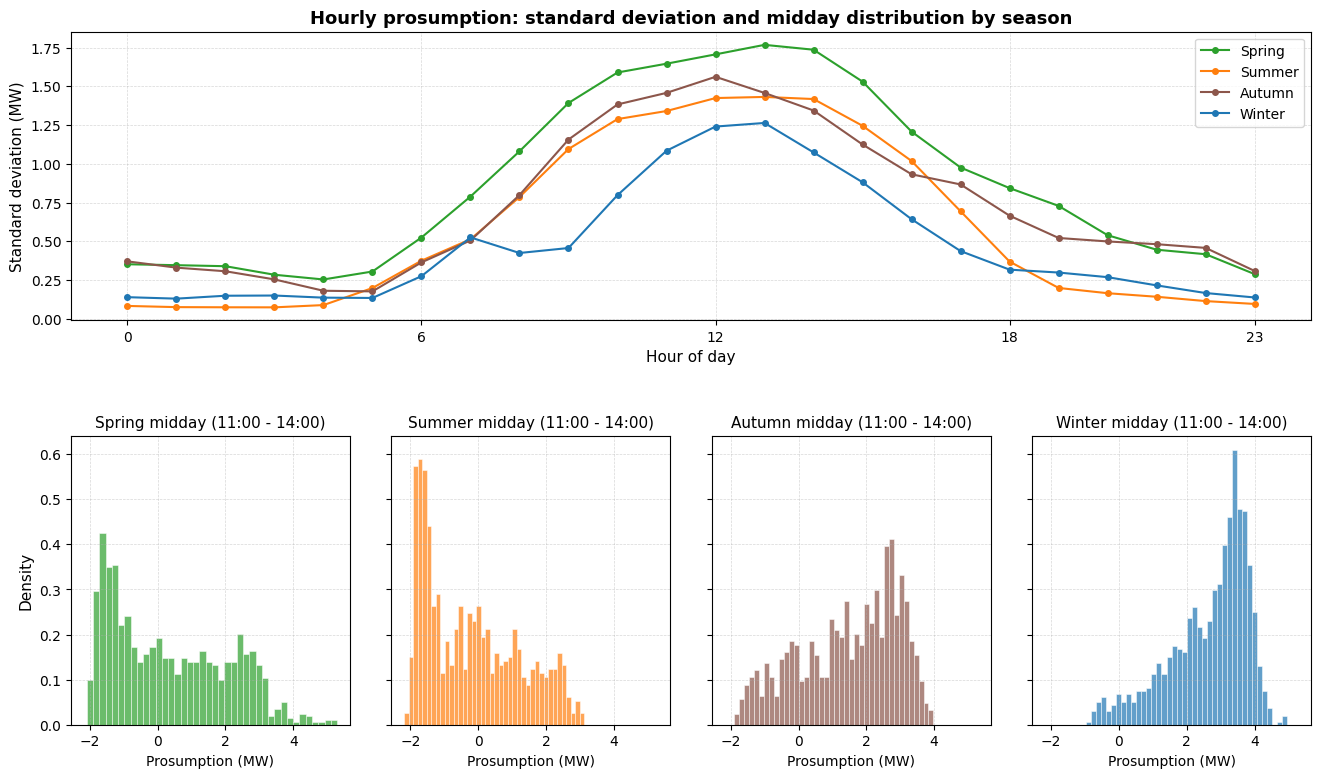

In [32]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1], hspace=0.4, wspace=0.15)

# --- Top Row: Hourly standard deviation by season ---
ax = fig.add_subplot(gs[0, :])

# 1. UPDATED: Loop over SEASON_ORDER to ensure legend matches bottom row
for season in SEASON_ORDER: 
    months = SEASON_MONTHS[season]
    sub = df[df["month"].isin(months)]
    hstd = sub.groupby("hour")["prosumption"].std()
    
    # 2. UPDATED: Added color=SEASON_COLORS[season] to unify the color palette
    ax.plot(hstd.index, hstd.values, "-o", markersize=4, linewidth=1.5,
            label=season.capitalize(), color=SEASON_COLORS[season])

ax.set_title("Hourly prosumption: standard deviation and midday distribution by season", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of day", fontsize=11)
ax.set_ylabel("Standard deviation (MW)", fontsize=11)

# 3. UPDATED: Simplified x-axis ticks to logical 6-hour chunks
ax.set_xticks([0, 6, 12, 18, 23])

ax.legend(fontsize=10, loc="upper right")
ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)


# --- Bottom Row: Midday (11:00-14:00) histograms ---
season_axes = []
for i, season in enumerate(SEASON_ORDER):
    # 4. UPDATED: Apply sharex and sharey to force identical scales across all 4 panels
    if i == 0:
        ax_hist = fig.add_subplot(gs[1, i])
    else:
        ax_hist = fig.add_subplot(gs[1, i], sharex=season_axes[0], sharey=season_axes[0])
    season_axes.append(ax_hist)

    x = midday.loc[midday["season"] == season, "prosumption"].dropna().to_numpy()

    ax_hist.hist(x, bins=40, color=SEASON_COLORS[season], alpha=0.7, 
                 density=True, edgecolor="white", linewidth=0.5)

    ax_hist.set_title(f"{season.capitalize()} midday (11:00 - 14:00)", fontsize=11)
    ax_hist.set_xlabel("Prosumption (MW)")
    ax_hist.grid(linestyle="--", linewidth=0.5, alpha=0.5)
    
    # Hide the y-axis labels on the inner plots to reduce clutter now that they are shared
    if i > 0:
        ax_hist.tick_params(labelleft=False)

# 5. UPDATED: Removed the clunky ax.text() and just use a standard ylabel on the first panel
season_axes[0].set_ylabel("Density", fontsize=11)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [28]:
winter_std = (
    df.loc[df["month"].isin(SEASON_MONTHS["Winter"])]
    .groupby("hour")["prosumption"]
    .std()
)

spring_std = (
    df.loc[df["month"].isin(SEASON_MONTHS["Spring"])]
    .groupby("hour")["prosumption"]
    .std()
)

winter_avg_std = winter_std.mean()
spring_avg_std = spring_std.mean()

print(f"Average hourly std of prosumption in Winter: {winter_avg_std:.3f} MW")
print(f"Average hourly std of prosumption in Spring: {spring_avg_std:.3f} MW")

# Compare March-June average prosumption in 2020 vs the same months in 2019
months = [3, 4, 5]

avg_2019 = (
    df.loc[(df.index.year == 2019) & (df.index.month.isin(months)), "prosumption"]
    .mean()
)
avg_2020 = (
    df.loc[(df.index.year == 2020) & (df.index.month.isin(months)), "prosumption"]
    .mean()
)

pct_diff = (avg_2020 - avg_2019) / avg_2019 * 100

print(f"Average prosumption (Mar-May 2019): {avg_2019:.3f} MW")
print(f"Average prosumption (Mar-May 2020): {avg_2020:.3f} MW")
print(f"Percentage difference (2020 vs 2019): {pct_diff:.2f}%")

# Optional: monthly breakdown
for m in months:
    avg_2019_m = (
        df.loc[(df.index.year == 2019) & (df.index.month == m), "prosumption"]
        .mean()
    )
    avg_2020_m = (
        df.loc[(df.index.year == 2020) & (df.index.month == m), "prosumption"]
        .mean()
    )
    pct_diff_m = (avg_2020_m - avg_2019_m) / avg_2019_m * 100
    print(
        f"{pd.Timestamp(year=2019, month=m, day=1).strftime('%B')}: "
        f"2019={avg_2019_m:.3f} MW, 2020={avg_2020_m:.3f} MW, "
        f"% diff={pct_diff_m:.2f}%"
    )

Average hourly std of prosumption in Winter: 0.473 MW
Average hourly std of prosumption in Spring: 0.879 MW
Average prosumption (Mar-May 2019): 1.874 MW
Average prosumption (Mar-May 2020): 1.612 MW
Percentage difference (2020 vs 2019): -14.01%
March: 2019=2.385 MW, 2020=2.323 MW, % diff=-2.60%
April: 2019=1.838 MW, 2020=1.426 MW, % diff=-22.42%
May: 2019=1.399 MW, 2020=1.077 MW, % diff=-23.01%


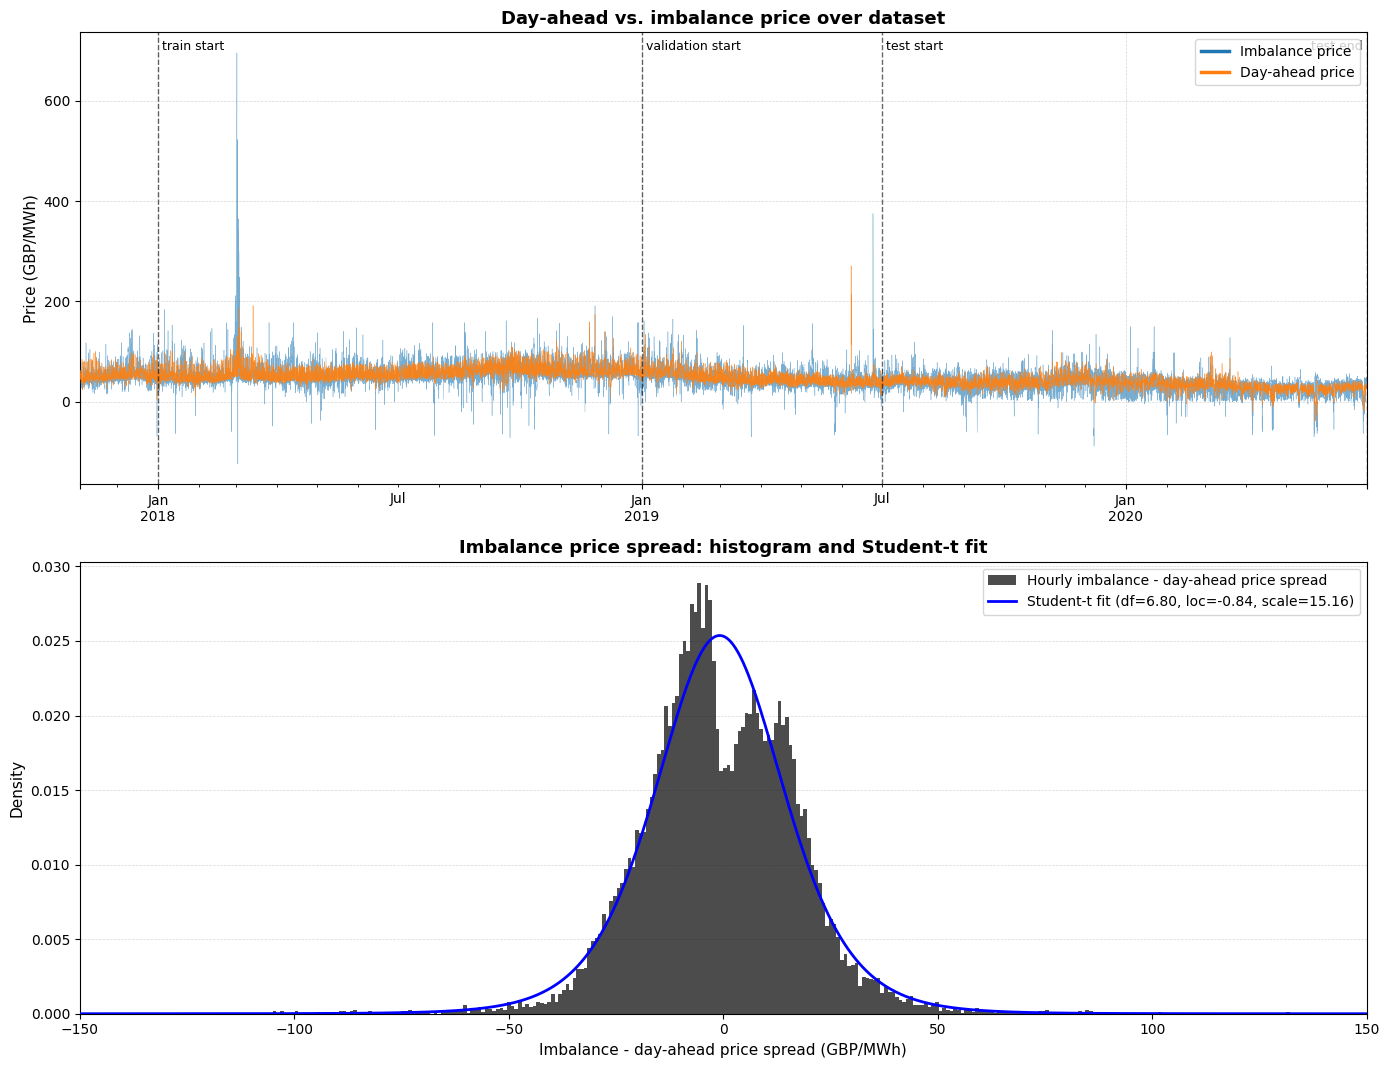

In [33]:
lower, upper = -150, 150
spread_clip = spread[(spread >= lower) & (spread <= upper)].dropna()

t_dof, t_loc, t_scale = stats.t.fit(spread_clip)

x_axis = np.linspace(lower, upper, 1000)
pdf_t = stats.t.pdf(x_axis, df=t_dof, loc=t_loc, scale=t_scale)


fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# --- Top: day-ahead and imbalance prices over time ---
ax = axes[0]

# Plot separately to enforce zorder and transparency
df["imb"].plot(ax=ax, linewidth=0.3, alpha=0.6, color="tab:blue", label="Imbalance price", zorder=2)
df["da"].plot(ax=ax, linewidth=0.3, alpha=0.9, color="tab:orange", label="Day-ahead price", zorder=3)

for split_date, label in [
    (TRAIN_START, "train start"),
    (VAL_START, "validation start"),
    (TEST_START, "test start"),
    (TEST_END, "test end"),
]:
    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6, zorder=4)
    
    # Conditional alignment to prevent 'test end' from clipping
    if label == "test end":
        ax.text(split_date, ax.get_ylim()[1] * 0.98, f"{label} ",
                fontsize=9, va="top", ha="right", color="black", zorder=5)
    else:
        ax.text(split_date, ax.get_ylim()[1] * 0.98, f" {label}",
                fontsize=9, va="top", ha="left", color="black", zorder=5)

ax.set_xlabel("") 
ax.set_ylabel("Price (GBP/MWh)", fontsize=11)
ax.set_title("Day-ahead vs. imbalance price over dataset", fontsize=13, fontweight="bold")

# 1. UPDATED: Capture the legend object
leg = ax.legend(loc="upper right")

# 2. UPDATED: Loop through the lines in the legend and make them fully opaque and thicker
for line in leg.get_lines():
    line.set_alpha(1.0)
    line.set_linewidth(2.5)

ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)


# --- Bottom: imbalance-price spread distribution ---
ax = axes[1]
ax.hist(
    spread,
    bins=1000,
    density=True,
    color="black",
    alpha=0.7,
    label="Hourly imbalance - day-ahead price spread",
    zorder=2
)
ax.plot(
    x_axis,
    pdf_t,
    "b-",
    linewidth=2,
    label=f"Student-t fit (df={t_dof:.2f}, loc={t_loc:.2f}, scale={t_scale:.2f})",
    zorder=3
)

ax.set_xlim(lower, upper)
ax.set_xlabel("Imbalance - day-ahead price spread (GBP/MWh)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Imbalance price spread: histogram and Student-t fit", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=1)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()